# California Housing - Automated Valuation Model

In [6]:
data = fetch_california_housing(as_frame=True)
df = data.frame
print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedHouseVal  
0      

In [11]:
import numpy as np
import pandas as pd
import folium
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# data prep
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
X = df[['Latitude', 'Longitude', 'MedInc']]
y = data.target

# holdout
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# model fit
knn = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn.fit(X_train_scaled, y_train)

# evaluation on test 
predictions = knn.predict(X_test_scaled)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f" - - evaluation scores - -")
print(f"Model R2 Score: {r2:.2f}") # 
print(f"Avg Error (MAE): ${mae*100000:.0f}")


# visualise - 100 representative points 
test_df_plot = X_test.head(100).copy()
test_scaled_plot = scaler.transform(test_df_plot)
test_df_plot['Price'] = knn.predict(test_scaled_plot)

m = folium.Map(location=[36.7, -119.4], zoom_start=6, tiles='OpenStreetMap')

for i, row in test_df_plot.iterrows():
    c = 'red' if row['Price'] > 3 else 'blue'
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,        
        color='black',    
        weight=0.5,        
        fill=True,
        fill_color=c,       
        fill_opacity=0.7,
        popup=f"Predicted prcie: ${row['Price']*100:.1f}k"
    ).add_to(m)

m.save("mapa.html")
m # visualization display

 - - evaluation scores - -
Model R2 Score: 0.76
Avg Error (MAE): $36676


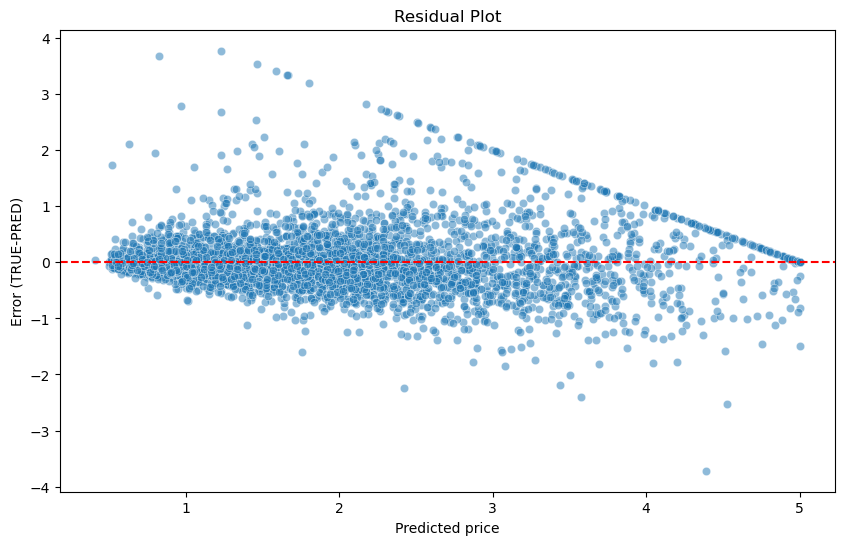

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted price')
plt.ylabel('Error (TRUE-PRED)')
plt.show()

Residuals plot:
- Most points are placed around 0, this means their prices based on location and medInc attributes has low bias, altough model has problem with more expensive prices as error has significantly bigger outliers on the graph. 
- Heteroskedasticity: variance of residuals is not constant across all levels, causes points to scatter unequally with the values changes (e.g. a wealthy person eating cheap food represents a heteroscedastic relationship, because high income increases the variance of food expenditure; a high income allows for expensive meals but doesn't mandate them)

Result interpretation/drawing conclusions:
- the model is useful but shall not be used as a final verdict, more as decision support 
- it has showed that location and medInc attribute determine in 76% (R^2) the price of real estate
- map shows binary result: red and blue dots
- MAE is quite high - 36k$, also model is not reliable for high value real estates
- dataset California Housing - old dataset based on 1990 U.S census
